# Empirical vs Simulated Brain Maps

For a chosen timestep, plot the brain activity from the **empirical** signal alongside the **simulated** signal of each model, plus the **difference** map and a **scatter** of simulated against empirical z-scored values.

Setup cells handle data, models and the surface adapter. Each model gets its own self-contained plotting cell at the bottom. Change `TIMESTEP` to focus on a different frame; everything else flows from that.

Adapted from `wholebrain_comparison_plots.ipynb` and styled to match the smooth, gouraud-shaded "cartoon" rendering of typical paper figures (viridis for value, coolwarm for difference).

In [50]:
import io
import os
import sys
import subprocess
from contextlib import redirect_stdout
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import nibabel as nib
import numpy as np
import torch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm
from nilearn import datasets, surface
from scipy import stats

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'examples':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

In [51]:
WHOLEBRAIN_URL = 'https://github.com/dagush/WholeBrain.git'
WHOLEBRAIN_DIR = PROJECT_ROOT / '.cache' / 'WholeBrain'

if not WHOLEBRAIN_DIR.exists():
    WHOLEBRAIN_DIR.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ['git', 'clone', '--depth', '1', WHOLEBRAIN_URL, str(WHOLEBRAIN_DIR)],
        check=True,
    )

if str(WHOLEBRAIN_DIR) not in sys.path:
    sys.path.insert(0, str(WHOLEBRAIN_DIR))

from WholeBrain.Utils.Plotting.plot3DBrain import plotColorView

wholebrain_commit = subprocess.check_output(
    ['git', '-C', str(WHOLEBRAIN_DIR), 'rev-parse', '--short', 'HEAD'],
    text=True,
).strip()
print(f'WholeBrain commit: {wholebrain_commit}')

WholeBrain commit: 0acef9b


## Configuration

`TIMESTEP` selects which frame of the trajectory is rendered. `SUBJECT_INDEX` picks which subject from the batch to use; the other models inherit the same initial state so the comparison is paired.

In [52]:
DATASET_TYPE = 'ts_young'
DATA_PATH = 'data/ts_young/ts_young_TR0.72.mat'
LSD_DATA_DIR = 'data/lsd'
CHECKPOINT_DIR = 'checkpoints'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

TIMESTEP = 1          # <-- change this to inspect a different frame
SUBJECT_INDEX = 0     # <-- which subject in the batch to plot

N_TIMEPOINTS = 120
MAX_PATHS = 2
MODELS_TO_PLOT = ['Hopf (Grid)', 'Hybrid Hopf', 'Neural SDE']

SURFACE_MESH = 'fsaverage5'
SURFACE_KIND = 'pial'
BRAIN_VIEW = 'Lh-lateral'
CMAP_VALUE = 'viridis'
CMAP_DIFF = 'coolwarm'
RENDER_MODE = 'gouraud'
SHADOWED = True
LIGHTING_BIAS = 0.2

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SAVE_DIR = PROJECT_ROOT / 'paper' / 'images' / 'wholebrain'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device       : {DEVICE}')
print(f'Timestep     : {TIMESTEP}')
print(f'Subject idx  : {SUBJECT_INDEX}')
print(f'Save dir     : {SAVE_DIR}')

Device       : cpu
Timestep     : 1
Subject idx  : 0
Save dir     : /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain


In [53]:
from src.dataset import create_data_loaders, load_dataset
from src.training import HopfConfig

cfg = HopfConfig()
cfg.dataset_type = DATASET_TYPE
cfg.data_path = DATA_PATH
cfg.lsd_data_dir = LSD_DATA_DIR
cfg.use_wandb = False
cfg.dt_min = 0.05

dataset = load_dataset(cfg, DEVICE)
window_size = min(N_TIMEPOINTS, dataset.n_timepoints // 2)

_, _, _, test_intra_loader = create_data_loaders(
    dataset=dataset,
    window_size=window_size,
    batch_size=cfg.batch_size,
    n_windows_per_epoch=cfg.n_windows_per_epoch,
    train_ratio=cfg.train_ratio,
    val_ratio=cfg.val_ratio,
    seed=cfg.seed,
    device=DEVICE,
)

batch = next(iter(test_intra_loader))
if len(batch) == 4:
    ts_target, _, patient_ids, control = batch
elif len(batch) == 3:
    ts_target, _, patient_ids = batch
    control = None
else:
    raise ValueError(f'Unexpected batch structure: {len(batch)} items')

ts_target = ts_target[:MAX_PATHS, :, :N_TIMEPOINTS]
if control is not None:
    control = control[:MAX_PATHS]
initial_state = ts_target[:, :, 0]

print(f'n_rois       : {dataset.n_rois}')
print(f'n_timepoints : {dataset.n_timepoints}')
print(f'target batch : {tuple(ts_target.shape)}')

Loaded dataset:
  - subjects=94  ROIs=100  T=1200
  - FC shape=torch.Size([100, 100])  dtype=torch.complex64  dt=0.72s
  - control_dims=0
n_rois       : 100
n_timepoints : 1200
target batch : (2, 100, 120)


In [54]:
from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ('gnn_hopf', 'GNN Hopf'),
    ('hybrid_neural', 'Hybrid+Neural'),
    ('hybrid_hopf', 'Hybrid Hopf'),
    ('nsde', 'Neural SDE'),
    ('hopf', 'Hopf'),
]


def short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (' (Grid)' if 'grid' in lower else '')
    return stem


models = {}
for ckpt_path in sorted(Path(CHECKPOINT_DIR).glob(f'*{DATASET_TYPE}*.pt')):
    model, model_type, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
    label = short_label(ckpt_path.stem)
    if model.n_rois != dataset.n_rois:
        continue
    if label not in MODELS_TO_PLOT:
        continue
    if label in models:
        continue
    models[label] = model
    print(f'Loaded {label:16s} ({model_type})')

missing = [name for name in MODELS_TO_PLOT if name not in models]
if missing:
    print(f'Warning: no checkpoint found for {missing}')

Loaded Hopf (Grid)      (CoupledHopfModel)
Loaded Hybrid Hopf      (HybridHopfModel)
Loaded Neural SDE       (NeuralSDE)


In [55]:
def forward_kwargs_for(model) -> dict:
    kwargs = {'n_steps': N_TIMEPOINTS}
    if control is not None and getattr(model, 'n_control_dims', 0) > 0 and control.shape[-1] > 0:
        kwargs['control'] = control
    return kwargs


ts_preds = {}
for name, model in models.items():
    with torch.no_grad():
        ts_preds[name] = model.forward(initial_state=initial_state, **forward_kwargs_for(model)).cpu()
    print(f'{name:16s} -> {tuple(ts_preds[name].shape)}')

Hopf (Grid)      -> (2, 100, 120)
Hybrid Hopf      -> (2, 100, 120)
Neural SDE       -> (2, 100, 120)


## Surface adapter and comparison helper

`build_schaefer_cortex` returns the fsaverage mesh and the Schaefer parcel-to-vertex map used by `plotColorView`. `prepare_roi_activity` reshapes a prediction tensor into a `(roi, time)` array.

In [56]:
SUPPORTED_SURFACE_ROIS = set(range(100, 1001, 100))


@lru_cache(maxsize=12)
def build_schaefer_cortex(n_rois: int, mesh: str = 'fsaverage5', surface_kind: str = 'pial'):
    if n_rois not in SUPPORTED_SURFACE_ROIS:
        raise ValueError(f'Schaefer parcels must be one of {sorted(SUPPORTED_SURFACE_ROIS)}; got {n_rois}.')

    surface_files = {
        'infl': ('infl_left', 'infl_right'),
        'pial': ('pial_left', 'pial_right'),
        'white': ('white_left', 'white_right'),
    }
    if surface_kind not in surface_files:
        raise ValueError(f"surface_kind must be one of {sorted(surface_files)}, got {surface_kind!r}.")

    atlas = datasets.fetch_atlas_schaefer_2018(n_rois=n_rois, yeo_networks=7, resolution_mm=2)
    labels_img = nib.load(atlas['maps'])
    fsaverage = datasets.fetch_surf_fsaverage(mesh=mesh)

    labels_left = np.rint(
        surface.vol_to_surf(labels_img, fsaverage.pial_left, interpolation='nearest_most_frequent')
    ).astype(int) - 1
    labels_right = np.rint(
        surface.vol_to_surf(labels_img, fsaverage.pial_right, interpolation='nearest_most_frequent')
    ).astype(int) - 1

    surface_left_key, surface_right_key = surface_files[surface_kind]
    return {
        'model_L': nib.load(getattr(fsaverage, surface_left_key)),
        'model_R': nib.load(getattr(fsaverage, surface_right_key)),
        'map_L': labels_left,
        'map_R': labels_right,
    }


def prepare_roi_activity(array_like, *, n_rois: int, subject_index: int = 0, complex_mode: str = 'real'):
    arr = array_like.detach().cpu().numpy() if torch.is_tensor(array_like) else np.asarray(array_like)
    if arr.ndim == 3:
        arr = arr.mean(axis=0) if subject_index is None else arr[int(subject_index)]
    elif arr.ndim != 2:
        raise ValueError(f'Expected a 2-D or 3-D array, got shape {arr.shape}.')

    if np.iscomplexobj(arr):
        if complex_mode == 'real':
            arr = arr.real
        elif complex_mode == 'imag':
            arr = arr.imag
        elif complex_mode == 'abs':
            arr = np.abs(arr)
        else:
            raise ValueError("complex_mode must be one of: 'real', 'imag', 'abs'.")

    arr = np.asarray(arr, dtype=float)
    if arr.shape[0] != n_rois and arr.shape[1] == n_rois:
        arr = arr.T
    if arr.shape[0] != n_rois:
        raise ValueError(f'Could not align timeseries with n_rois={n_rois}. Final shape was {arr.shape}.')
    return arr


# Pre-build the cortex so each per-model cell is fast.
_CORTEX = build_schaefer_cortex(dataset.n_rois, mesh=SURFACE_MESH, surface_kind=SURFACE_KIND)
print('Cortex ready:', sorted(_CORTEX))

[fetch_atlas_schaefer_2018] Dataset found in /home/hpc/dsaa/dsaa110h/nilearn_data/schaefer_2018

Cortex ready: ['map_L', 'map_R', 'model_L', 'model_R']


In [119]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def _zscore(values: np.ndarray) -> np.ndarray:
    centered = values - np.nanmean(values)
    scale = np.nanstd(centered)
    return centered / (scale + 1e-6)


def plot_empirical_vs_simulated(
    name: str,
    ts_empirical: torch.Tensor,
    ts_simulated: torch.Tensor,
    *,
    timestep: int = 0,
    subject_index: int = 0,
    complex_mode: str = 'real',
    view: str = 'Lh-lateral',
    cmap_value: str = 'viridis',
    cmap_diff: str = 'coolwarm',
    render_mode: str = 'gouraud',
    shadowed: bool = True,
    lighting_bias: float = 0.7,
    diff_clip_percentile: float = 99.0,
    cbar_width_frac: float = 0.8,
    cbar_height_frac: float = 0.6,
    save_path: Path | None = None,
):
    """Render the 4-panel "Empirical vs Simulated Maps" figure for a single model."""
    emp_full = prepare_roi_activity(ts_empirical, n_rois=dataset.n_rois,
                                    subject_index=subject_index, complex_mode=complex_mode)
    sim_full = prepare_roi_activity(ts_simulated, n_rois=dataset.n_rois,
                                    subject_index=subject_index, complex_mode=complex_mode)

    if not 0 <= timestep < emp_full.shape[1]:
        raise IndexError(f'timestep {timestep} out of bounds for length {emp_full.shape[1]}')

    emp_z = _zscore(emp_full[:, timestep])
    sim_z = _zscore(sim_full[:, timestep])
    diff = sim_z - emp_z

    value_lim = float(np.percentile(np.abs(np.concatenate([emp_z, sim_z])), 99.0))
    value_lim = max(value_lim, 1e-3)
    diff_lim = float(np.percentile(np.abs(diff), diff_clip_percentile))
    diff_lim = max(diff_lim, 1e-3)

    norm_value = Normalize(vmin=-value_lim, vmax=value_lim)
    # Plain Normalize on the symmetric diff range. TwoSlopeNorm caused the
    # colorbar's auto-locator to drop the boundary ticks silently.
    norm_diff = Normalize(vmin=-diff_lim, vmax=diff_lim)
    cmap_v = plt.get_cmap(cmap_value)
    cmap_d = plt.get_cmap(cmap_diff)

    fig = plt.figure(figsize=(9.0, 2.2))
    # Generous colorbar row; the actual colorbar is an inset inside it so its
    # width/height can be controlled (passing `cax=` to fig.colorbar makes the
    # `aspect=` kwarg a no-op, so we size the cax ourselves).
    gs = fig.add_gridspec(
        nrows=2, ncols=5,
        height_ratios=[1.0, 0.12],
        width_ratios=[1.0, 1.0, 1.0, 0.18, 0.8],
        hspace=0.05, wspace=0.05,
    )
    ax_emp = fig.add_subplot(gs[0, 0])
    ax_sim = fig.add_subplot(gs[0, 1])
    ax_diff = fig.add_subplot(gs[0, 2])
    ax_scat = fig.add_subplot(gs[0, 4])

    # Container axes reserve gridspec space for each colorbar; the inset is the
    # actual visible colorbar, centered and sized as a fraction of the cell so
    # both colorbars come out with the same width and a sensible aspect ratio.
    # The value colorbar spans two cells (emp + sim), so its inset is narrower
    # in relative terms to match the diff colorbar's absolute width.
    cax_value_outer = fig.add_subplot(gs[1, 0:2])
    cax_value_outer.set_axis_off()
    cax_diff_outer = fig.add_subplot(gs[1, 2])
    cax_diff_outer.set_axis_off()

    # Value container spans 2 columns vs diff's 1 column, so halve its frac
    # to give both colorbars the same on-page width.
    cax_value = inset_axes(
        cax_value_outer,
        width=f'{cbar_width_frac * 50:.1f}%',
        height=f'{cbar_height_frac * 100:.0f}%',
        loc='center',
        borderpad=0,
    )
    cax_diff = inset_axes(
        cax_diff_outer,
        width=f'{cbar_width_frac * 100:.1f}%',
        height=f'{cbar_height_frac * 100:.0f}%',
        loc='center',
        borderpad=0,
    )

    common = dict(mode=render_mode, shadowed=shadowed, lightingBias=lighting_bias)
    plotColorView(ax_emp, _CORTEX, {'func_L': emp_z, 'func_R': emp_z},
                  dataset.n_rois, view, cmap=cmap_v, norm=norm_value, **common)
    plotColorView(ax_sim, _CORTEX, {'func_L': sim_z, 'func_R': sim_z},
                  dataset.n_rois, view, cmap=cmap_v, norm=norm_value, **common)
    plotColorView(ax_diff, _CORTEX, {'func_L': diff, 'func_R': diff},
                  dataset.n_rois, view, cmap=cmap_d, norm=norm_diff, **common)

    ax_emp.set_title('Empirical', fontsize=13)
    ax_sim.set_title('Simulated', fontsize=13)
    ax_diff.set_title('Difference', fontsize=13)

    sm_value = ScalarMappable(norm=norm_value, cmap=cmap_v); sm_value.set_array([])
    sm_diff = ScalarMappable(norm=norm_diff, cmap=cmap_d); sm_diff.set_array([])

    cbar_v = fig.colorbar(sm_value, cax=cax_value, orientation='horizontal')
    cbar_v.ax.tick_params(labelsize=8)

    cbar_d = fig.colorbar(sm_diff, cax=cax_diff, orientation='horizontal')
    ticks_d = [-diff_lim, 0, diff_lim]
    cbar_d.set_ticks(ticks_d)
    cbar_d.set_ticklabels([f"{t:.2f}" for t in ticks_d])
    cbar_d.ax.tick_params(labelsize=8)

    r_val, p_val = stats.pearsonr(emp_z, sim_z)
    slope, intercept = np.polyfit(emp_z, sim_z, 1)
    x_line = np.linspace(emp_z.min(), emp_z.max(), 64)
    ax_scat.scatter(emp_z, sim_z, color='black', s=7, alpha=0.85)
    ax_scat.plot(x_line, slope * x_line + intercept, color='black', lw=1.2)
    ax_scat.set_xlabel('Empirical (z)')
    ax_scat.set_ylabel('Simulated (z)', labelpad=-4)
    ax_scat.spines['top'].set_visible(False)
    ax_scat.spines['right'].set_visible(False)
    ax_scat.set_xticks([-2, 0, 2])
    ax_scat.set_yticks([-2, 0, 2])
    ax_scat.margins(0.12)
    p_str = '< 0.001' if p_val < 0.001 else f'= {p_val:.3f}'
    ax_scat.text(
        0.04, 0.96,
        f'$r$ = {r_val:.2f}\n$p$ {p_str}',
        transform=ax_scat.transAxes,
        ha='left', va='top',
        fontsize=11,
    )

    t_seconds = timestep * float(dataset.dt)
    # fig.suptitle(
    #     f'{name} — Empirical vs Simulated Maps   (t = {t_seconds:.2f} s, frame {timestep})',
    #     fontsize=13, y=1.02,
    # )

    if save_path is not None:
        sp = Path(save_path)
        sp.parent.mkdir(parents=True, exist_ok=True)
        # Primary save (PDF when called with a .pdf path) in paper/images/...
        fig.savefig(sp, bbox_inches='tight')
        sp_str = str(sp)
        # PNG mirror in paper/images_png/...
        png_path = Path(sp_str.replace('/images/', '/images_png/')).with_suffix('.png')
        png_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(png_path, bbox_inches='tight', dpi=300)
        # SVG mirror in paper/images_svg/...
        svg_path = Path(sp_str.replace('/images/', '/images_svg/')).with_suffix('.svg')
        svg_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(svg_path, bbox_inches='tight')
        print(f'Saved {sp}')
        print(f'Saved {png_path}')
        print(f'Saved {svg_path}')

    return fig, {'r': r_val, 'p': p_val, 'value_lim': value_lim, 'diff_lim': diff_lim}

## Per-model figures

One cell per model. Each cell calls `plot_empirical_vs_simulated` with the model's predicted timeseries and the global `TIMESTEP` / `SUBJECT_INDEX`.

In [120]:
%matplotlib inline

In [ ]:
MODEL_NAME = 'Hopf (Grid)'
fig, info = plot_empirical_vs_simulated(
    MODEL_NAME,
    ts_target,
    ts_preds[MODEL_NAME],
    timestep=TIMESTEP,
    subject_index=SUBJECT_INDEX,
    view=BRAIN_VIEW,
    cmap_value=CMAP_VALUE,
    cmap_diff=CMAP_DIFF,
    render_mode=RENDER_MODE,
    shadowed=SHADOWED,
    lighting_bias=0.5,
    save_path=SAVE_DIR / f'empirical_vs_simulated__hopf_grid__t{TIMESTEP:03d}.pdf',
)
print(info)
plt.show()

Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/empirical_vs_simulated__hybrid_hopf__t001.pdf
Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images_png/wholebrain/empirical_vs_simulated__hybrid_hopf__t001.png
Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images_svg/wholebrain/empirical_vs_simulated__hybrid_hopf__t001.svg
{'r': np.float64(0.8581003428037329), 'p': np.float64(3.9958973022482385e-30), 'value_lim': 2.2302804900644655, 'diff_lim': 1.4811811271909718}


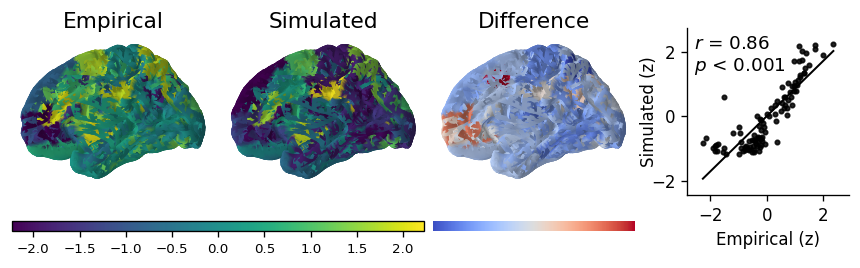

In [115]:
MODEL_NAME = 'Hybrid Hopf'
fig, info = plot_empirical_vs_simulated(
    MODEL_NAME,
    ts_target,
    ts_preds[MODEL_NAME],
    timestep=TIMESTEP,
    subject_index=SUBJECT_INDEX,
    view=BRAIN_VIEW,
    cmap_value=CMAP_VALUE,
    cmap_diff=CMAP_DIFF,
    render_mode=RENDER_MODE,
    shadowed=SHADOWED,
    lighting_bias=0.5,
    save_path=SAVE_DIR / f'empirical_vs_simulated__hybrid_hopf__t{TIMESTEP:03d}.pdf',
)
print(info)
plt.show()

Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images/wholebrain/empirical_vs_simulated__neural_sde__t001.pdf
Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images_png/wholebrain/empirical_vs_simulated__neural_sde__t001.png
Saved /home/hpc/dsaa/dsaa110h/projects/neuroscience_control/paper/images_svg/wholebrain/empirical_vs_simulated__neural_sde__t001.svg
{'r': np.float64(0.6645902325286791), 'p': np.float64(4.727208465647385e-14), 'value_lim': 2.4701897266889117, 'diff_lim': 1.953425997237075}


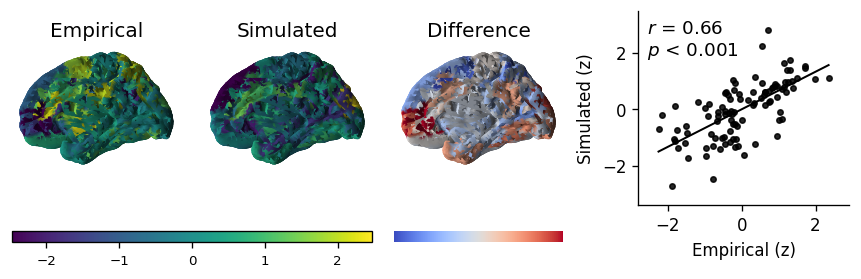

In [61]:
MODEL_NAME = 'Neural SDE'
fig, info = plot_empirical_vs_simulated(
    MODEL_NAME,
    ts_target,
    ts_preds[MODEL_NAME],
    timestep=TIMESTEP,
    subject_index=SUBJECT_INDEX,
    view=BRAIN_VIEW,
    cmap_value=CMAP_VALUE,
    cmap_diff=CMAP_DIFF,
    render_mode=RENDER_MODE,
    shadowed=SHADOWED,
    lighting_bias=LIGHTING_BIAS,
    save_path=SAVE_DIR / f'empirical_vs_simulated__neural_sde__t{TIMESTEP:03d}.pdf',
)
print(info)
plt.show()